In [ ]:
# ==========================================
# Cell 1: Mount Google Drive and Load Batch 1
# ==========================================

from google.colab import drive
import os
import urllib.request
import h5py
import scipy.io
import matplotlib.pyplot as plt
import numpy as np
import pickle

# Mount Google Drive
drive.mount('/content/drive')

# Folder to store dataset
SAVE_DIR = "/content/drive/MyDrive/MITR_battery_dataset"
os.makedirs(SAVE_DIR, exist_ok=True)

# Batch 1 information
FILE_NAME = "batch1.mat"
FILE_PATH = os.path.join(SAVE_DIR, FILE_NAME)

DOWNLOAD_URL = (
    "https://data.matr.io/1/api/v1/file/"
    "5c86c0b5fa2ede00015ddf66/download"
)

# Download only if it doesn't already exist
if not os.path.exists(FILE_PATH):
    print("Downloading Batch 1 (this only happens once)...")
    urllib.request.urlretrieve(DOWNLOAD_URL, FILE_PATH)
    print("Download complete.\n")
else:
    print("Batch 1 already exists.\n")

# Verify file
size_gb = os.path.getsize(FILE_PATH) / (1024**3)

print(f"Dataset : {FILE_NAME}")
print(f"Location: {FILE_PATH}")
print(f"Size    : {size_gb:.2f} GB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Batch 1 already exists.

Dataset : batch1.mat
Location: /content/drive/MyDrive/MITR_battery_dataset/batch1.mat
Size    : 2.82 GB


In [ ]:


# plt.figure(figsize=(10, 5))
# for i in range(batch['summary'].shape[0]):
#     summary = f[batch['summary'][i, 0]]
#     cycles = np.hstack(summary['cycle'][0, :].tolist())
#     qd = np.hstack(summary['QDischarge'][0, :].tolist())
#     plt.plot(cycles, qd, alpha=0.5)

# plt.title('Discharge Capacity Fade Across All Cells')
# plt.xlabel('Cycle Number')
# plt.ylabel('Discharge Capacity (Ah)')
# plt.grid(True)
# plt.show()

# A NEW BEGINNING

# PHASE 1: DATA LOADING AND CLEANING

In [ ]:

matFilename = '/content/drive/MyDrive/MITR_battery_dataset/batch1.mat'
# 1. Open the HDF5 file in read-only mode

f = h5py.File(matFilename, 'r')

batch = f['batch']

# Define metadata and exclusions
num_cells = batch['summary'].shape[0]
corrupted_cells = ['b1c8', 'b1c10', 'b1c12', 'b1c13', 'b1c22']
cleaned_cell_records = {}

print(f"File loaded successfully. Total cells found: {num_cells}")

File loaded successfully. Total cells found: 46


Chunk 2: Outer Loop Setup (Cell Level)
This block sets up the dictionary to hold our clean data and begins iterating through the cells, skipping the ones with known hardware logging failures.

In [ ]:
print("Filtering and extracting cycles...")

for i in range(num_cells):
    cell_id = f"b1c{i}"

    if cell_id in corrupted_cells:
        continue

    cycle_life = int(f[batch['cycle_life'][i, 0]][()][0, 0])
    cycles_data = f[batch['cycles'][i, 0]]
    total_logged_cycles = cycles_data['I'].shape[0]

    valid_cycles = {}

    for j in range(total_logged_cycles):
        V_raw = np.hstack(f[cycles_data['V'][j, 0]][:])
        T_raw = np.hstack(f[cycles_data['T'][j, 0]][:])
        I_raw = np.hstack(f[cycles_data['I'][j, 0]][:])
        t_raw = np.hstack(f[cycles_data['t'][j, 0]][:])

        # Filter anomalous zero-fill cycles
        if len(V_raw) < 5 or np.max(V_raw) <= 0.5 or np.max(I_raw) == 0.0:
            continue

        valid_cycles[j] = {
            'V': V_raw,
            'T': T_raw,
            'I': I_raw,
            't': t_raw,
            'RUL': cycle_life - j
        }

    if valid_cycles:
        cleaned_cell_records[cell_id] = valid_cycles

Filtering and extracting cycles...


In [ ]:
print(f"Data loading complete. Functional cells parsed: {len(cleaned_cell_records)}")

# Verify the structure of the first stored cell
first_key = list(cleaned_cell_records.keys())[0]
first_cycle = list(cleaned_cell_records[first_key].keys())[0]

print(f"\nSample data from {first_key}, cycle {first_cycle}:")
print(f"Voltage array shape: {cleaned_cell_records[first_key][first_cycle]['V'].shape}")
print(f"Target RUL: {cleaned_cell_records[first_key][first_cycle]['RUL']}")

Data loading complete. Functional cells parsed: 41

Sample data from b1c0, cycle 1:
Voltage array shape: (1087,)
Target RUL: 1189


#PHASE 2: PREPROCESSING  - RANDOM FOREST

In [ ]:
print("=== STARTING PHASE 2: PREPROCESSING ===")
FIXED_STEPS = 100
processed_samples = []

# Iterate through the dictionary we built in Phase 1
for cell_id, cycles in cleaned_cell_records.items():
    for cycle_idx, data in cycles.items():
        V_raw = data['V']
        T_raw = data['T']
        I_raw = data['I']
        t_raw = data['t']
        rul = data['RUL']

        # Create grids for interpolation mapping
        # original_grid is the actual length of the raw data (e.g., 0 to 1 over 600 steps)
        # uniform_grid is our target length (0 to 1 over exactly 100 steps)
        original_grid = np.linspace(0, 1, len(V_raw))
        uniform_grid = np.linspace(0, 1, FIXED_STEPS)

        # Resample all arrays to exactly 100 steps to enforce strict shapes
        V_resampled = np.interp(uniform_grid, original_grid, V_raw)
        T_resampled = np.interp(uniform_grid, original_grid, T_raw)
        I_resampled = np.interp(uniform_grid, original_grid, I_raw)
        t_resampled = np.interp(uniform_grid, original_grid, t_raw)

        # Stack them side-by-side into a 2D matrix: shape (100, 4)
        cycle_matrix = np.column_stack((V_resampled, T_resampled, I_resampled, t_resampled))

        processed_samples.append({
            'Cell_ID': cell_id,
            'Cycle_Index': cycle_idx,
            'Matrix': cycle_matrix,
            'RUL': rul
        })

print(f"Preprocessing complete. Total uniform cycles prepared: {len(processed_samples)}")
print(f"Shape of each cycle matrix: {processed_samples[0]['Matrix'].shape}")

=== STARTING PHASE 2: PREPROCESSING ===
Preprocessing complete. Total uniform cycles prepared: 34300
Shape of each cycle matrix: (100, 4)


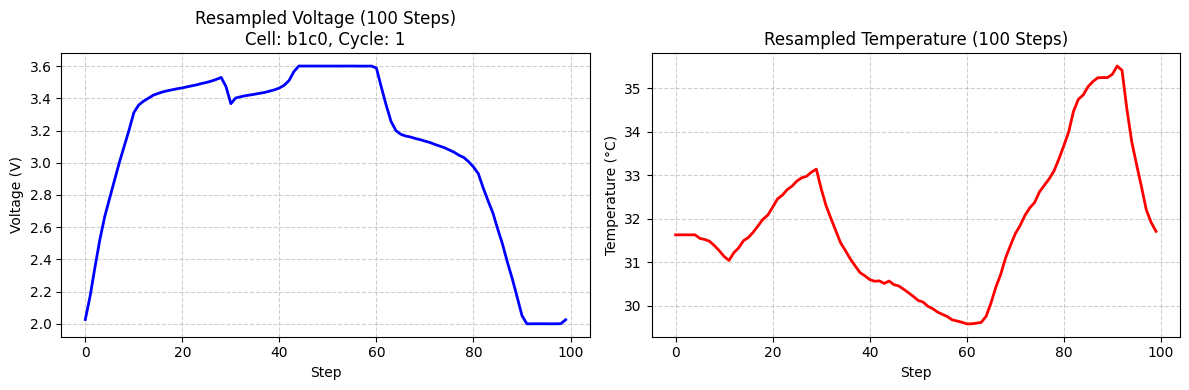

In [ ]:
# Grab the very first processed sample to visualize it
sample = processed_samples[0]
matrix = sample['Matrix']

# In our matrix, column 0 is Voltage, column 1 is Temp
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(matrix[:, 0], color='blue', linewidth=2)
plt.title(f"Resampled Voltage (100 Steps)\nCell: {sample['Cell_ID']}, Cycle: {sample['Cycle_Index']}")
plt.xlabel("Step")
plt.ylabel("Voltage (V)")
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(matrix[:, 1], color='red', linewidth=2)
plt.title(f"Resampled Temperature (100 Steps)")
plt.xlabel("Step")
plt.ylabel("Temperature (°C)")
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# PHASE 3 - Leak-Free Partitioning & Splitting Strategy

In [ ]:
import numpy as np

print("=== STARTING PHASE 3: LEAK-FREE SPLITTING ===")

# 1. Identify all unique functional batteries
unique_cells = list(cleaned_cell_records.keys())
print(f"Total unique batteries to split: {len(unique_cells)}")

# 2. Randomly select 80% of the batteries for the training pool
np.random.seed(42)
train_cell_pool = np.random.choice(unique_cells, size=int(len(unique_cells) * 0.8), replace=False)
test_cell_pool = [cell for cell in unique_cells if cell not in train_cell_pool]

print(f"Training on {len(train_cell_pool)} batteries. Testing on {len(test_cell_pool)} batteries.")

# 3. Build the actual training and testing matrices
X_seq_train, X_seq_test = [], []
X_flat_train, X_flat_test = [], []
y_train, y_test = [], []

for sample in processed_samples:
    cell_id = sample['Cell_ID']
    matrix = sample['Matrix']
    rul = sample['RUL']

    # Flatten the (100, 4) matrix into 400 linear features for the Random Forest
    flat_vector = matrix.flatten()

    if cell_id in train_cell_pool:
        X_seq_train.append(matrix)
        X_flat_train.append(flat_vector)
        y_train.append(rul)
    else:
        X_seq_test.append(matrix)
        X_flat_test.append(flat_vector)
        y_test.append(rul)

# 4. Convert python lists to final machine-learning-ready NumPy arrays
X_seq_train, X_seq_test = np.array(X_seq_train), np.array(X_seq_test)
X_flat_train, X_flat_test = np.array(X_flat_train), np.array(X_flat_test)
y_train, y_test = np.array(y_train), np.array(y_test)

print("\n=== SPLIT RESULTS ===")
print(f"Random Forest Inputs -> X_train: {X_flat_train.shape}, X_test: {X_flat_test.shape}")
print(f"LSTM Inputs          -> X_train: {X_seq_train.shape}, X_test: {X_seq_test.shape}")
print(f"Target RUL Labels    -> y_train: {y_train.shape}, y_test: {y_test.shape}")

=== STARTING PHASE 3: LEAK-FREE SPLITTING ===
Total unique batteries to split: 41
Training on 32 batteries. Testing on 9 batteries.

=== SPLIT RESULTS ===
Random Forest Inputs -> X_train: (27142, 400), X_test: (7158, 400)
LSTM Inputs          -> X_train: (27142, 100, 4), X_test: (7158, 100, 4)
Target RUL Labels    -> y_train: (27142,), y_test: (7158,)


# Phase 4A: Random Forest Training

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("=== STARTING PHASE 4A: FAST RANDOM FOREST BASELINE ===")

# 1. Aggressively clipped hyper-parameters for weak hardware
rf_model = RandomForestRegressor(
    n_estimators=50,  # Reduced from 100
    max_depth=5,      # Reduced from 10
    n_jobs=-1,
    random_state=42,
    verbose=2
)

# 2. Train on a 5,000-cycle slice instead of the full 27,000
print("Training lightweight Random Forest on 5,000 cycles...")
rf_model.fit(X_flat_train[:15000], y_train[:15000])
print("Training complete.")

# 3. Evaluate on the full testing set
print("\nEvaluating model on test data...")
y_pred_rf = rf_model.predict(X_flat_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("\n=== RANDOM FOREST PERFORMANCE ===")
print(f"Mean Absolute Error (MAE):      {mae_rf:.2f} cycles")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f} cycles")
print(f"R² Score:                       {r2_rf:.4f}")

=== STARTING PHASE 4A: FAST RANDOM FOREST BASELINE ===
Training lightweight Random Forest on 5,000 cycles...
building tree 1 of 50
building tree 2 of 50


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


building tree 3 of 50
building tree 4 of 50
building tree 5 of 50
building tree 6 of 50
building tree 7 of 50
building tree 8 of 50
building tree 9 of 50
building tree 10 of 50
building tree 11 of 50
building tree 12 of 50
building tree 13 of 50
building tree 14 of 50
building tree 15 of 50
building tree 16 of 50
building tree 17 of 50
building tree 18 of 50
building tree 19 of 50
building tree 20 of 50
building tree 21 of 50
building tree 22 of 50
building tree 23 of 50
building tree 24 of 50
building tree 25 of 50
building tree 26 of 50
building tree 27 of 50
building tree 28 of 50
building tree 29 of 50
building tree 30 of 50
building tree 31 of 50
building tree 32 of 50
building tree 33 of 50
building tree 34 of 50
building tree 35 of 50
building tree 36 of 50
building tree 37 of 50
building tree 38 of 50
building tree 39 of 50
building tree 40 of 50


[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:  1.6min


building tree 41 of 50
building tree 42 of 50
building tree 43 of 50
building tree 44 of 50
building tree 45 of 50
building tree 46 of 50
building tree 47 of 50
building tree 48 of 50
building tree 49 of 50
building tree 50 of 50
Training complete.

Evaluating model on test data...

=== RANDOM FOREST PERFORMANCE ===
Mean Absolute Error (MAE):      67.55 cycles
Root Mean Squared Error (RMSE): 92.17 cycles
R² Score:                       0.8583


[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:  2.1min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done  50 out of  50 | elapsed:    0.0s finished


However, notice the gap between your MAE (67.55 cycles) and your RMSE (92.17 cycles). Because RMSE squares the errors before averaging them, it heavily penalizes large mistakes. This tells us that while the Random Forest is usually within ~67 cycles of the truth, it occasionally gets completely confused and makes massive errors. This happens because the model lacks historical memory; it is looking at a single cycle in a vacuum and getting tricked by ambiguous degradation states.

#PHASE 4B: LSTM Training (The Deep Learning Approach)

We are now going to feed the model the 3D tensors we built in Phase 3 (X_seq_train). Instead of looking at 400 flattened points and guessing, the LSTM will read the 100-step sequences chronologically, understanding how voltage drops and temperature rises over time during a single charge.

In [24]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

print("=== STARTING PHASE 4B: LSTM TRAINING ===")
print("TensorFlow automatically detecting GPU...")

# 1. Define the Sequential Architecture
# Input shape matches our uniform resampled matrices: (100 steps, 4 features)
sequence_input = layers.Input(shape=(100, 4), name="Cycle_Sequence")

# First LSTM layer reads the sequence and returns a sequence to the next layer
x = layers.LSTM(64, return_sequences=True)(sequence_input)
x = layers.Dropout(0.2)(x) # Dropout prevents overfitting

# Second LSTM layer reads the sequences and condenses it into a final understanding
x = layers.LSTM(32, return_sequences=False)(x)
x = layers.Dropout(0.2)(x)

# Final Dense regression head to output a single RUL number
dense_layer = layers.Dense(32, activation='relu')(x)
output_layer = layers.Dense(1, activation='linear', name="RUL_Prediction")(dense_layer)

lstm_model = Model(inputs=sequence_input, outputs=output_layer)

# 2. Compile the model
lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print(lstm_model.summary())
print("\nTraining LSTM Network on the full 27,142 cycles...")

# 3. Train the Model
# We use 10% of the training data as a live validation check during epochs
history = lstm_model.fit(
    X_seq_train[:15000], y_train[:15000],
    validation_split=0.1,
    epochs=30,
    batch_size=128,     # Processes 128 cycles at a time on the GPU
    verbose=1
)

# 4. Predict and Evaluate on the completely unseen Test Set
print("\nEvaluating LSTM on unseen test data...")
y_pred_lstm = lstm_model.predict(X_seq_test).flatten()

mae_lstm = mean_absolute_error(y_test, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
r2_lstm = r2_score(y_test, y_pred_lstm)

print("\n=== LSTM PERFORMANCE ===")
print(f"Mean Absolute Error (MAE):      {mae_lstm:.2f} cycles")
print(f"Root Mean Squared Error (RMSE): {rmse_lstm:.2f} cycles")
print(f"R² Score:                       {r2_lstm:.4f}")

=== STARTING PHASE 4B: LSTM TRAINING ===
TensorFlow automatically detecting GPU...


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Cycle_Sequence (InputLayer)     │ (None, 100, 4)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 100, 64)        │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ RUL_Prediction (Dense)          │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,169 (121.75 KB)

 Trainable params: 31,169 (121.75 KB)

 Non-trainable params: 0 (0.00 B)

None

Training LSTM Network on the full 27,142 cycles...
Epoch 1/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 336461.5625 - mae: 488.6180 - val_loss: 273510.8125 - val_mae: 427.5665
Epoch 2/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 291608.4688 - mae: 443.8958 - val_loss: 223709.3906 - val_mae: 375.2732
Epoch 3/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 231123.5156 - mae: 384.2533 - val_loss: 168082.4531 - val_mae: 320.5659
Epoch 4/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 172240.7969 - mae: 326.7633 - val_loss: 123973.7734 - val_mae: 283.4260
Epoch 5/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 129294.7500 - mae: 285.0074 - val_loss: 94795.3047 - val_mae: 254.4373
Epoch 6/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 97743.8516 - mae: 244.4702 - val_loss: 58616.8789 - val_mae: 180.6367
Epoch 7/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 77839.7812 - mae: 215.4956 - val_loss: 41133.5156 - val_mae: 159.4082
Epoch 8/30
106/10

# PHASE 4C: Advanced Time-Series LSTM

we are generating these rolling windows strictly per battery to prevent data leakage where the end of Battery A's life accidentally overlaps with the beginning of Battery B's life.

In [28]:

print("=== STARTING PHASE 4C: ADVANCED SLIDING WINDOW LSTM (SCALED) ===")

SEQ_LEN = 10

X_window_train, y_window_train = [], []
X_window_test, y_window_test = [], []

print("Constructing chronological rolling windows per battery...")

for cell_id in unique_cells:
    cell_cycles = [s for s in processed_samples if s['Cell_ID'] == cell_id]
    cell_cycles = sorted(cell_cycles, key=lambda x: x['Cycle_Index'])

    for i in range(len(cell_cycles) - SEQ_LEN):
        window = cell_cycles[i : i + SEQ_LEN]
        target_rul = window[-1]['RUL']
        window_features = np.array([cycle['Matrix'].flatten() for cycle in window])

        if cell_id in train_cell_pool:
            X_window_train.append(window_features)
            y_window_train.append(target_rul)
        else:
            X_window_test.append(window_features)
            y_window_test.append(target_rul)

X_window_train, y_window_train = np.array(X_window_train), np.array(y_window_train)
X_window_test, y_window_test = np.array(X_window_test), np.array(y_window_test)

=== STARTING PHASE 4C: ADVANCED SLIDING WINDOW LSTM (SCALED) ===
Constructing chronological rolling windows per battery...


In [29]:
from sklearn.preprocessing import MinMaxScaler
# =====================================================================
# THE FIX: NORMALIZATION (Scaling the 3D features to 0-1 range)
# =====================================================================
print("Normalizing features to prevent gradient paralysis...")
scaler = MinMaxScaler()

# Reshape to 2D for the scaler, then reshape back to 3D for the LSTM
samples_tr, steps, features = X_window_train.shape
X_train_flat = X_window_train.reshape(-1, features)
X_train_scaled = scaler.fit_transform(X_train_flat).reshape(samples_tr, steps, features)

samples_te = X_window_test.shape[0]
X_test_flat = X_window_test.reshape(-1, features)
X_test_scaled = scaler.transform(X_test_flat).reshape(samples_te, steps, features)

# =====================================================================

window_input = layers.Input(shape=(SEQ_LEN, 400), name="Multi_Cycle_Window")

x = layers.LSTM(64, return_sequences=True)(window_input)
x = layers.Dropout(0.2)(x)
x = layers.LSTM(32, return_sequences=False)(x)
x = layers.Dropout(0.2)(x)

dense_layer = layers.Dense(32, activation='relu')(x)
output_layer = layers.Dense(1, activation='linear')(dense_layer)

advanced_lstm = Model(inputs=window_input, outputs=output_layer)
advanced_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print("\nTraining Scaled Time-Series LSTM on 15,000 samples...")

history = advanced_lstm.fit(
    X_train_scaled[:15000], y_window_train[:15000],
    validation_split=0.1,
    epochs=30,
    batch_size=128,
    verbose=1
)


Normalizing features to prevent gradient paralysis...

Training Scaled Time-Series LSTM on 15,000 samples...
Epoch 1/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 330669.8125 - mae: 484.5868 - val_loss: 304735.5938 - val_mae: 466.8358
Epoch 2/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 291600.0938 - mae: 445.2833 - val_loss: 255428.1250 - val_mae: 418.6875
Epoch 3/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 236234.9531 - mae: 389.2948 - val_loss: 196690.9062 - val_mae: 365.1769
Epoch 4/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 179691.4844 - mae: 332.9764 - val_loss: 144873.8906 - val_mae: 321.8765
Epoch 5/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 136083.2969 - mae: 290.5600 - val_loss: 110820.4688 - val_mae: 291.3044
Epoch 6/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 111419.5078 - mae: 269.0452 - val_loss: 94635.0469 - val_mae: 274.3036
Epoch 7/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 101372.1016 - mae: 261.4066 - val_los

In [30]:
print("\nEvaluating Scaled Advanced LSTM on unseen test data...")
y_pred_adv_lstm = advanced_lstm.predict(X_test_scaled).flatten()

mae_adv = mean_absolute_error(y_window_test, y_pred_adv_lstm)
rmse_adv = np.sqrt(mean_squared_error(y_window_test, y_pred_adv_lstm))
r2_adv = r2_score(y_window_test, y_pred_adv_lstm)

print("\n=== SCALED ADVANCED LSTM PERFORMANCE ===")
print(f"Mean Absolute Error (MAE):      {mae_adv:.2f} cycles")
print(f"Root Mean Squared Error (RMSE): {rmse_adv:.2f} cycles")
print(f"R² Score:                       {r2_adv:.4f}")


Evaluating Scaled Advanced LSTM on unseen test data...
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

=== SCALED ADVANCED LSTM PERFORMANCE ===
Mean Absolute Error (MAE):      58.81 cycles
Root Mean Squared Error (RMSE): 79.80 cycles
R² Score:                       0.8914


=== STARTING PHASE 5: VISUALIZATION AND RESULTS ===
Visualizing degradation tracking for Test Battery: b1c7


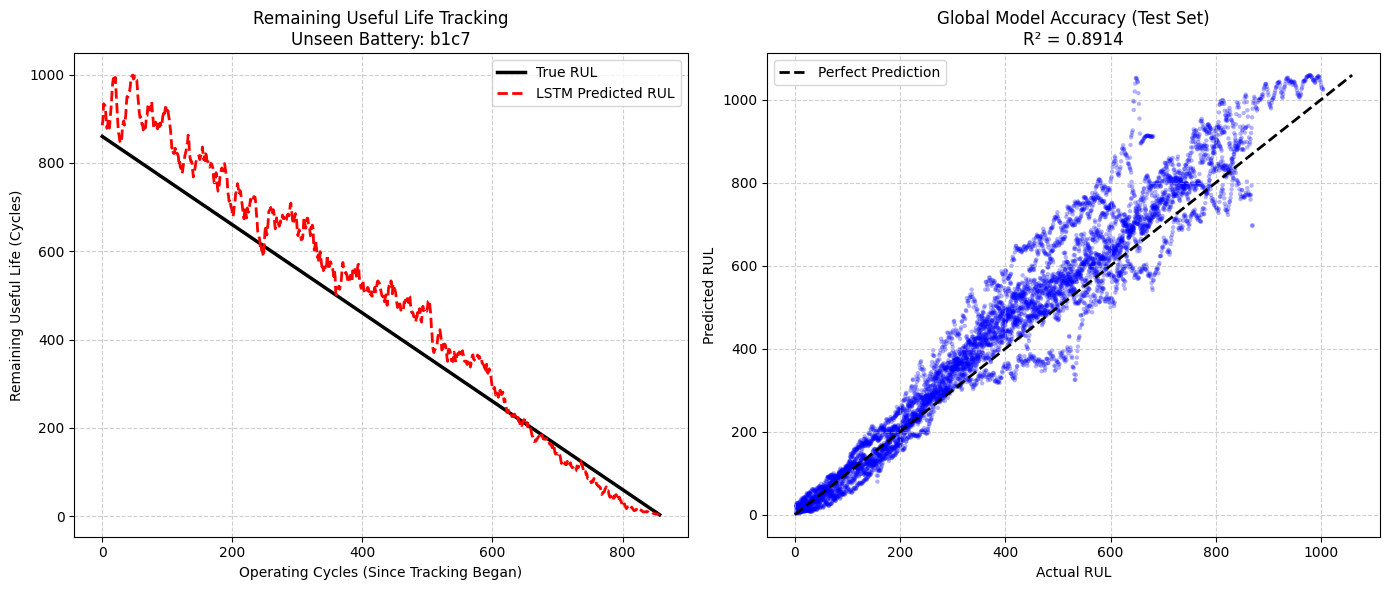

In [36]:
import matplotlib.pyplot as plt
import numpy as np

print("=== STARTING PHASE 5: VISUALIZATION AND RESULTS ===")

# 1. Isolate a single battery from the unseen test set
sample_test_cell = test_cell_pool[0]
print(f"Visualizing degradation tracking for Test Battery: {sample_test_cell}")

# Extract only the data for this specific battery
cell_indices = []
current_idx = 0

# We have to re-locate the test cell's indices within the scaled test array
for cell_id in unique_cells:
    if cell_id not in train_cell_pool:
        cell_cycles = [s for s in processed_samples if s['Cell_ID'] == cell_id]
        num_windows = len(cell_cycles) - SEQ_LEN

        if cell_id == sample_test_cell:
            target_indices = range(current_idx, current_idx + num_windows)
            break
        current_idx += num_windows

# 2. Get the specific true and predicted values for this battery
cell_y_true = y_window_test[target_indices]
cell_y_pred = y_pred_adv_lstm[target_indices]
cycle_numbers = range(len(cell_y_true))

# 3. Plot 1: RUL Tracking over Time
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(cycle_numbers, cell_y_true, label="True RUL", color='black', linewidth=2.5)
plt.plot(cycle_numbers, cell_y_pred, label="LSTM Predicted RUL", color='red', linestyle='--', linewidth=2)
plt.title(f"Remaining Useful Life Tracking\nUnseen Battery: {sample_test_cell}")
plt.xlabel("Operating Cycles (Since Tracking Began)")
plt.ylabel("Remaining Useful Life (Cycles)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# 4. Plot 2: Global Prediction Scatter (All Test Batteries)
plt.subplot(1, 2, 2)
plt.scatter(y_window_test, y_pred_adv_lstm, alpha=0.3, color='blue', edgecolors='none', s=10)
# Plot the perfect prediction line
max_val = max(np.max(y_window_test), np.max(y_pred_adv_lstm))
plt.plot([0, max_val], [0, max_val], color='black', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title(f"Global Model Accuracy (Test Set)\nR² = {r2_adv:.4f}")
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()